# **Tarea 1**                      Astrofísica Moderna
#### Juan Esteban Zapata
#### C.C. 1193151372

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Una partícula de masa en reposo $m_0$, energía $E_0$ y momento $p_0$ sufre una colisión elástica frontal (es decir, masas de partıculas sin alterar) con una masa estacionaria $M$. En la colisión, $M$ es golpeado directamente hacia adelante, con energía $E$ y momento $P$, dejando la primera partícula con energía $E_1$ y $p_1$. Calcule $P$ y $p_1$, ¿a qué se reducen estas expresiones en el límite clásico? Realice una simulación del feómeno acá expuesto.

#### Solución

El choque es elástico, entonces se conserva tanto la energía total relativista, como el momentum total relativista. Si suponemos que la partícula de masa $m_0$ se mueve, antes del choque a una velocidad $v_0$, y después del choque la velocidad de la misma es $v_f$ y $M$ adquiere una velocidad de $v_M$, la ecuación de la conservación de la energía es, en este caso:

$$ E = m_0 \gamma(v_0)c^2 + Mc^2 = m_0\gamma(v_f)c^2 + M\gamma(v_f)c^2$$

Donde el primer término es la energía relativista de $m_0$, el segundo es la energía en reposo de $M$, y el tercer y cuarto son las energías relativistas de $m_0$ y $M$ después del choque.

La conservación del momentum es, en este caso:

$$P_{TOT} = m_0\gamma(v_0)v_0 = m_0\gamma(v_f)v_f + M\gamma(v_M)v_M$$

In [2]:
c = 2.998e8 # m/s
def gamma(v):
    return 1/np.sqrt(1-v**2/c**2)

### ----------------------- ANTES DEL CHOQUE ------------------------ ###

v_0 = 0.5*c # Velocidad de la partícula m_0
m_0 = 1 # masa en reposo
m_r = gamma(v_0)*m_0 # masa relativista
p_0 = m_r * v_0 # Momento de la partícula m_0
E_0 = m_r * c**2 # Energía de la partícula m_0

M = 2  # Masa en reposo de la partícula M
E_Ma = M*c**2 # Energía en reposo de la partícula M

E_antes = E_0 + E_Ma # Energía total antes
P_antes = p_0 # Momentum lineal antes

Calculada ya la energía total relativista y el momento, y teniendo en cuenta que estas cantidades se conservan, falta entonces calcular el momento individual de cada partícula después del choque.

Aquí pude aprovecharme de la conservación del momento lineal para asignarle a $m$ o a $M$ una velocidad cualquiera después del impacto, calcular su momentum, y por la conservación del mismo, hallar el momentum de la otra partícula. Sin embargo, si bien ello garantizaría la conservación del momentum, no pasaría así con la energía. Esto da cuenta de que la velocidad que adquieren las partículas no es cuestión, **obviamente**, del azar. 

Intenté _mucha_ álgebra y no pude encontrar una ecuación algebraica que me sirviera para encontrar explícitamente ese factor de transferencia de momento para cada partícula (que depende de la velocidad $v_0$ y de las masas en reposo $m_0$ y $M$). Así que no tuve más remedio que encontrar "a la fuerza" ese número que además de hacer válida la conservación del momentum, también hiciera válida la conservación de la energía.

En el ciclo mostrado a continuación, trato de encontrar el coeficiente $\beta_M$ (la velocidad) de la partícula $M$ con la que se conserva la energía. Evidentemente $\beta_M$ debe ser menor que el coeficiente $\beta_0$, pues no tendría sentido que la partícula $M$ adquiriera una velocidad mayor que con la que venía $m_0$.

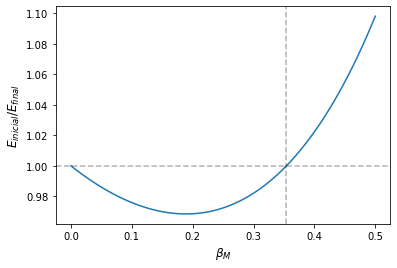

In [3]:
betas = np.linspace(0, 0.5, 100)
razon_energias = np.zeros_like(betas)

for i, b in enumerate(betas):
    v_M = b*c

    M_r = M*gamma(v_M)
    P = M_r * v_M

    p_1 = p_0 - P

    E_Md = np.sqrt(P**2*c**2+(M*c**2)**2)
    E_1 = np.sqrt(p_1**2*c**2+(m_0*c**2)**2)
    
    razon_energias[i] = (E_Md+E_1)/E_antes
    
plt.plot(betas, razon_energias)
plt.axhline(1, c='k', ls='--', alpha=0.3)
plt.axvline(0.354, c='k', ls='--', alpha=0.3)
plt.xlabel(r'$\beta_M$', fontsize=12)
plt.ylabel(r'$E_{inicial}/E_{final}$', fontsize=12);

Se encuentra que el valor de $\beta_M$ que hace que tanto la energía como el momentum se conserven es $\beta_M \approx 0.354$ (solo bajos las condiciones iniciales establecidas). A continuación recalculo e imprimo los momentos, y las energías:

In [4]:
bm = 0.354

v_M = bm*c
M_r = M*gamma(v_M)
P = M_r*v_M

p_1 = p_0 - P

E_Md = np.sqrt(P**2*c**2+(M*c**2)**2)
E_1 = np.sqrt(p_1**2*c**2+(m_0*c**2)**2)

print(f'Momento lineal antes del choque: {P_antes:.2f}\nMomento lineal despues del choque: {P+p_1:.2f}\n')
print(f'Energía antes del choque: {E_antes:.3e}\nEnergía despues del choque: {E_Md + E_1:.3e}\n')

Momento lineal antes del choque: 173089610.70
Momento lineal despues del choque: 173089610.70

Energía antes del choque: 2.835e+17
Energía despues del choque: 2.835e+17



### 2. Muestre que la colisión inelástica, la masa en reposo del objeto combinado es mayor que la suma de las masas en reposo originales. ¿Por cuánto más es mayor la masa?¿De dónde deriva este aumento?¿Qué significa esto?


#### Solución

Supongamos una patícula $m_1$ con velocidad $u_1$ choca con otra partícula $m_2$ con velocidad $u_2$, y forman una partícula de masa $m_3$.

Se conserva tanto el momento, como la energía relativista antes y después de la colisión. 

Partiendo de la conservación del momento lineal, y denotando con el subíndice $_1$ todo lo relacionado con la partícula 1, y con $_2$ y $_3$ lo respectivo a las partículas 2 y 3 respectivamente:

\begin{equation}
p_1 + p_2 = p_3 \\
m_1\gamma_1u_1 + m_2\gamma_2u_2 = p_3 = \frac{1}{c}\sqrt{E_3^2-m_3^2c^4}
\end{equation}

Elevando a ambos lados al cuadrado y multiplicando por $c^2$:

\begin{equation}
c^2m_1^2\gamma_1^2u_1^2 + c^2m_2^2\gamma_2^2u_2^2 = E_3^2 - m_3^2c^4
\end{equation}

Como se conserva la energía, entonces $E_3 = E_1 + E_2 = m_1\gamma_1c^2 + m_2\gamma_2c^2$, entonces:

\begin{equation}
c^2m_1^2\gamma_1^2u_1^2 + c^2m_2^2\gamma_2^2u_2^2 = (m_1^2\gamma_1^2c^4+m_2^2\gamma_2^2c^4+2m_1m_2\gamma_1\gamma_2c^4)-m_3^2c^4
\end{equation}

Dividiendo entre $c^4$ y reagrupando para despejar $m_3^2$: 

\begin{equation}
m_1^2\gamma_1^2\frac{u_1^2}{c^2} + m_2^2\gamma_2^2\frac{u_2^2}{c^2} - m_1^2\gamma_1^2 - m_2^2\gamma_2^2 - 2m_1m_2\gamma_1\gamma_2 = -m_3^2 \\
m_1^2\gamma_1^2\left(1-\frac{u_1^2}{c^2}\right) + m_2^2\gamma_2^2\left(1-\frac{u_2^2}{c^2}\right) + 2m_1m_2\gamma_1\gamma_2 = m_3^2
\end{equation}

Pero $\left(1-\frac{u_1^2}{c^2}\right) = \left(\frac{1}{\gamma_1^2}\right)$, y lo mismo con $\gamma_2$, queda entonces:

\begin{equation}
m_3 = \sqrt{m_1^2+m_2^2+2m_1m_2\gamma_1\gamma_2}
\tag{1}
\end{equation}

que es la expresión que buscábamos. También podemos ver que en el límite clásico $\gamma_1, \gamma_2 \rightarrow 1$ entonces $m_3 = \sqrt{(m_1+m_2)^2} = m_1+m_2$.

Como puede observarse, el incremento en la masa depende de los valores de $\gamma_1$ y $\gamma_2$, es decir, depende de la velocidad de las partículas. Antes de chocar, las partículas tienen cierta masa en reposo y cierta energía cinética. Al ser una colisión inelástica, significa que la energía cinética no se conserva, entonces teniendo en cuenta que la energía total se conserva siempre, esa energía cinética perdida debe manifestarse de otra manera. Esa disminución en la energía cinética se manifiesta ciertamente en el incremento en la energía en reposo de la partícula, es decir, incremento en la masa! Eso significa que entre más rápido va una partícula, mayor es su inercia y por tanto más difícil cambiar su estado de movimiento (acelerarla), ello pone límite a la velocidad de cualquier objeto con masa.

### 3. Dos partículas cuyas masas en reposo son $m_1$ y $m_2$ se mueven a lo largo de una línea recta con velocidades $u_1$ y $u_2$, medidas en la misma dirección. Chocan inelásticamente para formar una nueva partícula. Encuentre la masa en reposo y la velocidad de la nueva partícula. Realice una simulacion del fenómeno acá expuesto.

#### Solución

La masa en reposo de la partícula está dada por la ecuación (1). La energía se conserva, entonces la energía total de la partícula 3, la que forman 1 y 2 juntas, tiene una energía $E_3 = E_1 + E_2 = m_1\gamma_1c^2 + m_2\gamma_2c^2$.

Pero además $E_3 = m_3\gamma_3c^2$, entonces podemos despejar $\gamma_3$ para calcular su nueva velocidad:

\begin{equation}
\gamma_3 = \frac{m_1\gamma_1 + m_2\gamma_2}{\sqrt{m_1^2+m_2^2+2m_1m_2\gamma_1\gamma_2}}
\end{equation}

Teniendo el valor de $\gamma_3$, puede calcularse $u_3$ como sigue:

\begin{equation}
u_3 = c\cdot\sqrt{1-\frac{1}{\gamma_3^2}}
\end{equation}

In [5]:
m_1 = 1.2 # masa de m1
m_2 = 0.5 # masa de m2

u_1 = 0.5*c # velocidad de m1
u_2 = 0.3*c # velocidad de m2

g1 = gamma(u_1)
g2 = gamma(u_2)

m_3 = np.sqrt(m_1**2+m_2**2+2*m_1*m_2*g1*g2) # Segun ecuacion 1

print(f'La masa en reposo de la nueva partícula es: {m_3:.3f} MeV')

La masa en reposo de la nueva partícula es: 1.773 MeV


In [6]:
g3 = (m_1*g1+m_2*g2)/np.sqrt(m_1**2+m_2**2+2*m_1*m_2*g1*g2)

u_3 = c*np.sqrt(1-1/g3**2)

print(f'La velocidad de la nueva partícula es: {u_3/c:.3f} c')

La velocidad de la nueva partícula es: 0.372 c
